# Action potential waveforms are state-dependent
### Finding 2 of 5

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

For over a century, neuroscience has treated the action potential as a binary, all-or-none event, every spike functionally identical to the next. This paper asks whether that abstraction throws away real information. It turns out the shape of a single spike, not just whether or when it fired, varies with the input driving the neuron, varies more from spike to spike within one neuron than expected, and tracks the surrounding network state.

This notebook walks through one of the paper's five findings. See the [repo README](README.md) for the full picture and the other four notebooks.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AP1 = 'AP_empirical_paper_all_analyses'
sys.path.append(f'{AP1}/datasets/pvc-6/pvc6_helper_modules/')
from pvc6_plotting import plot_confusion_matrix, plot_feature_importance_categorical, plot_beta_weights_combined

PVC6_PICKLE_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/'

## Electrical stimulation causally influences spike waveform

**Finding:** injecting current into a neuron changes the shape of its spikes, not just how often it fires.

We drove the same neuron (pvc-6, Cell 1) with three current patterns: steady, ramping, and noisy ("pink noise"). A random forest classifier using only spike-shape features decodes which pattern produced a given spike with 78.4% ± 0.7% out-of-fold accuracy across 1000 repeated 5-fold splits (chance is 33%). Zooming into the noisy-current trials alone, waveform features predict the size of the current in the 200 ms before a spike (ridge regression, R² = 0.72), driven mostly by peak sharpness and decay rate.

**Figure:** out-of-fold confusion matrix and feature importances for the stimulus-type classifier (Fig. 3C); significant beta weights and bootstrapped R² for the 200 ms ridge regression (Fig. 3F).

Out-of-fold accuracy: 0.784 +/- 0.007 (1000 repeats, chance = 0.333)


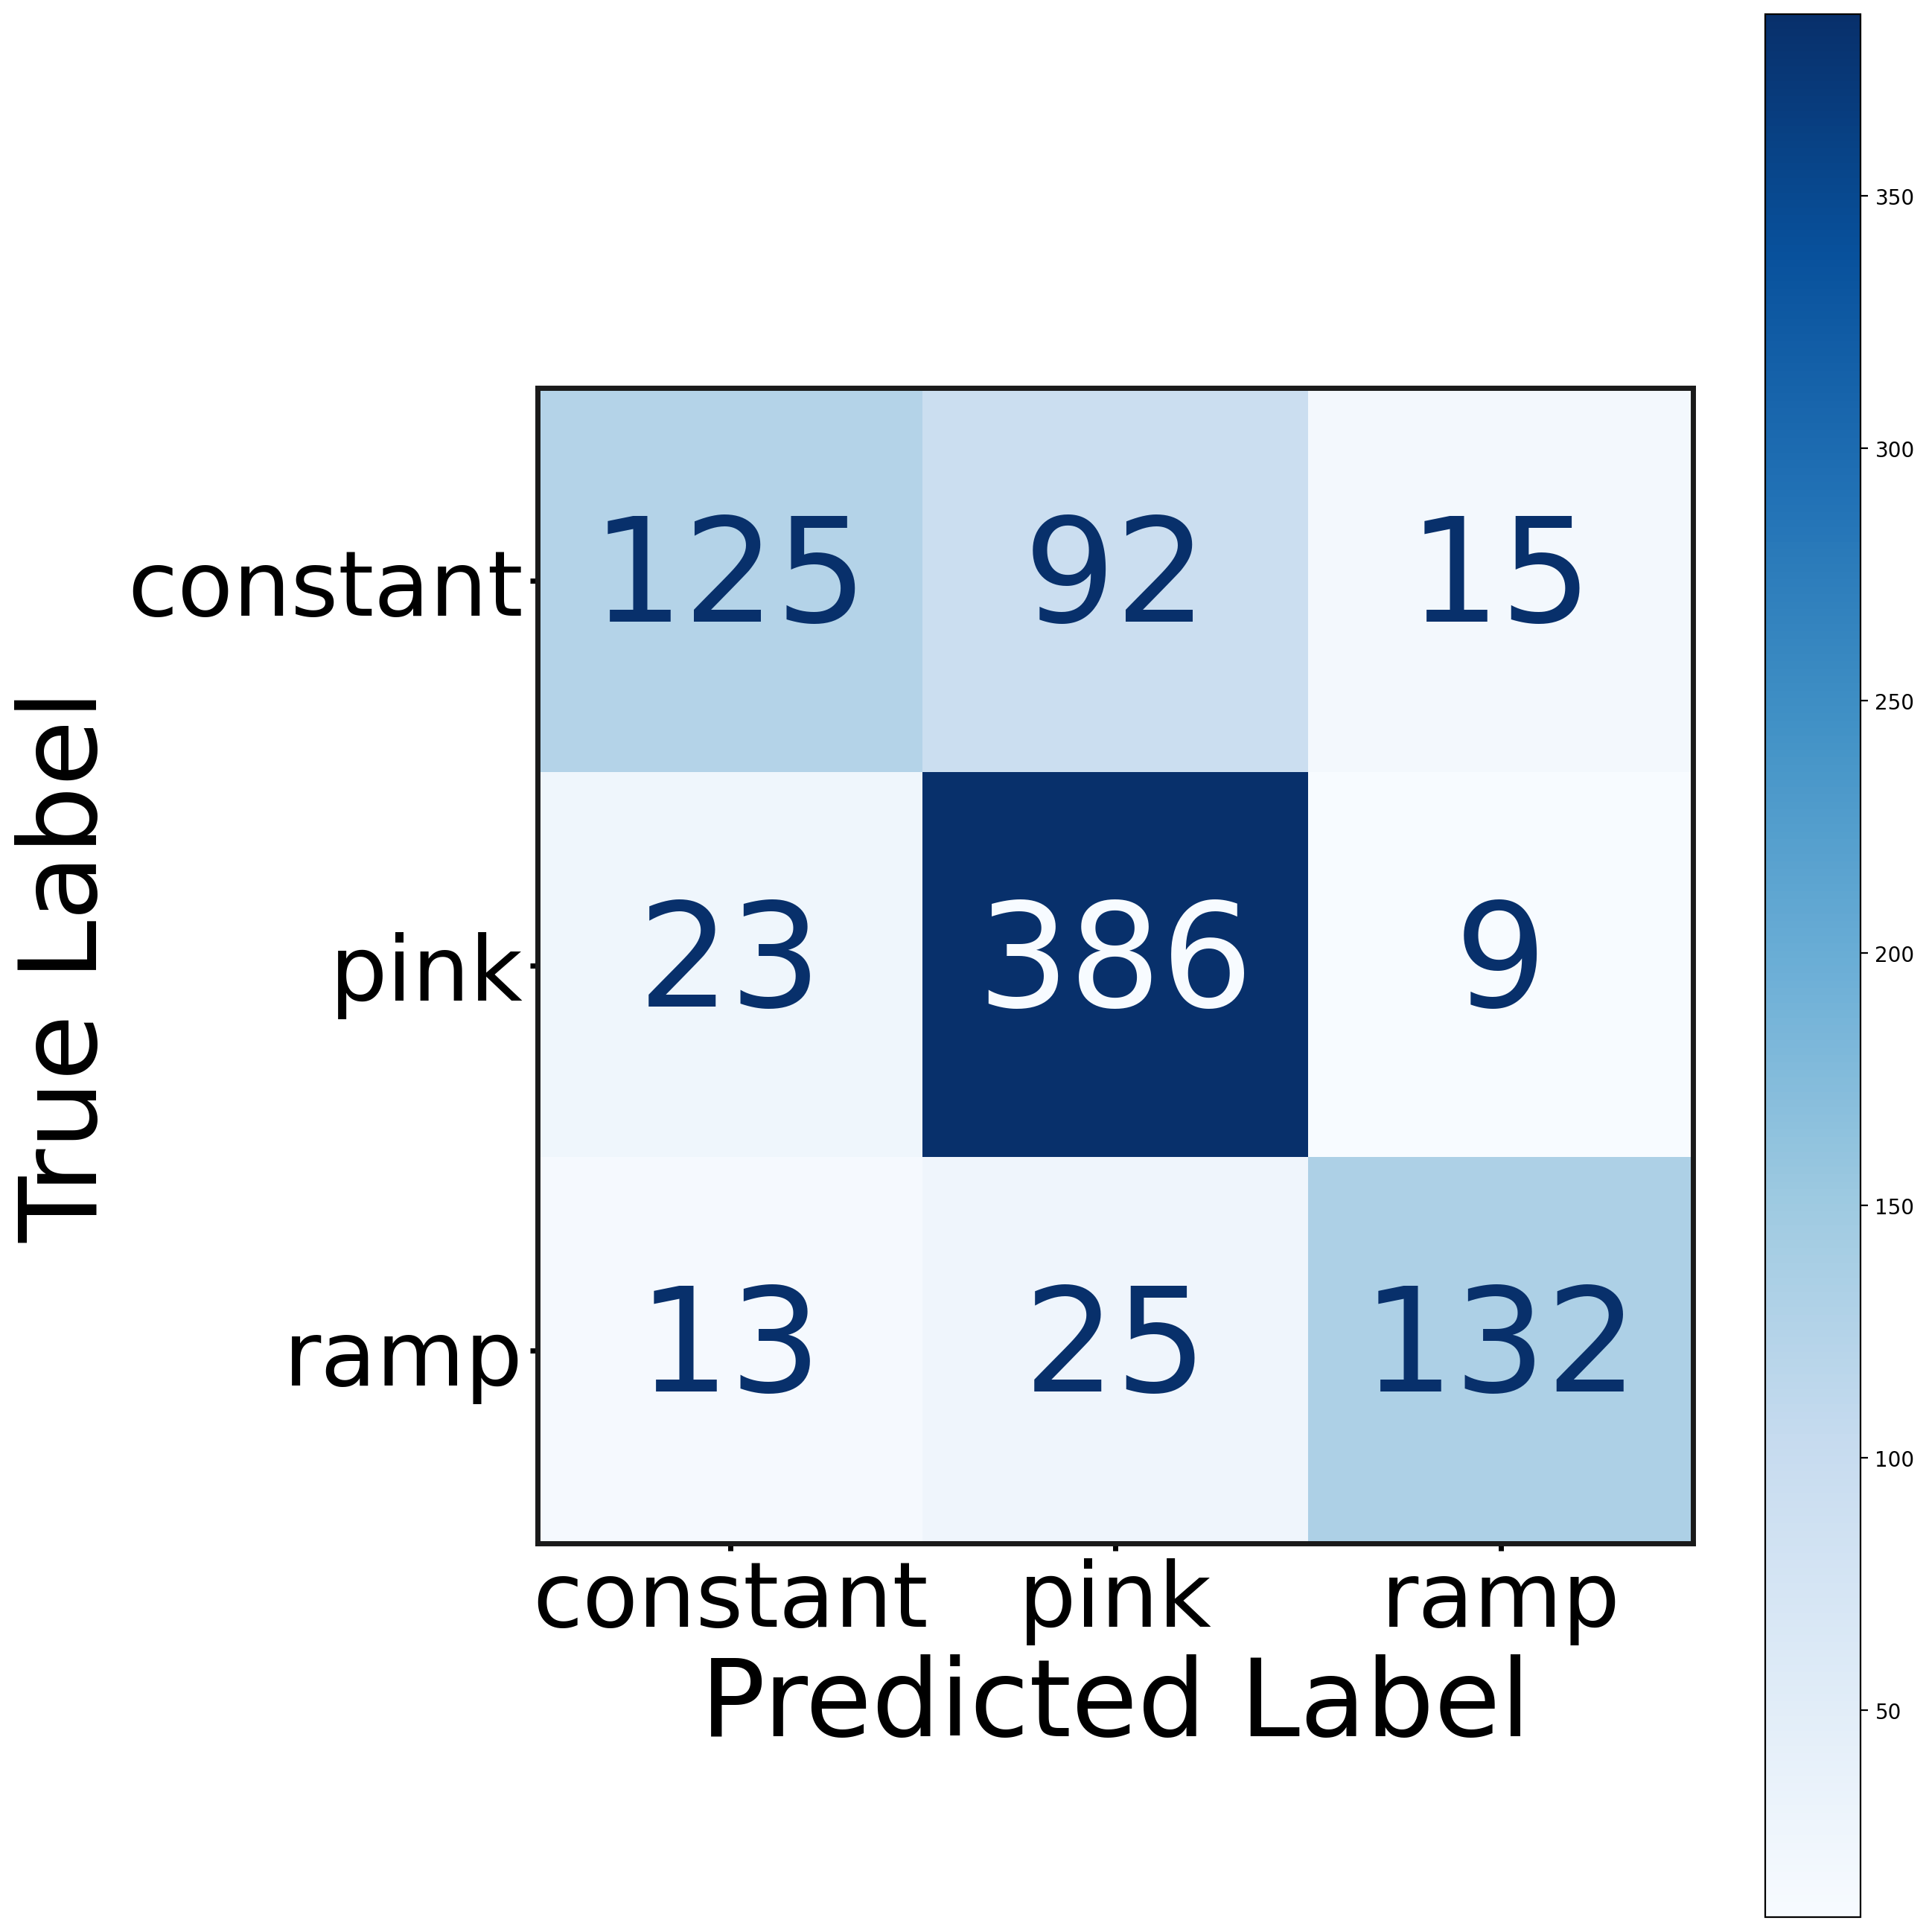

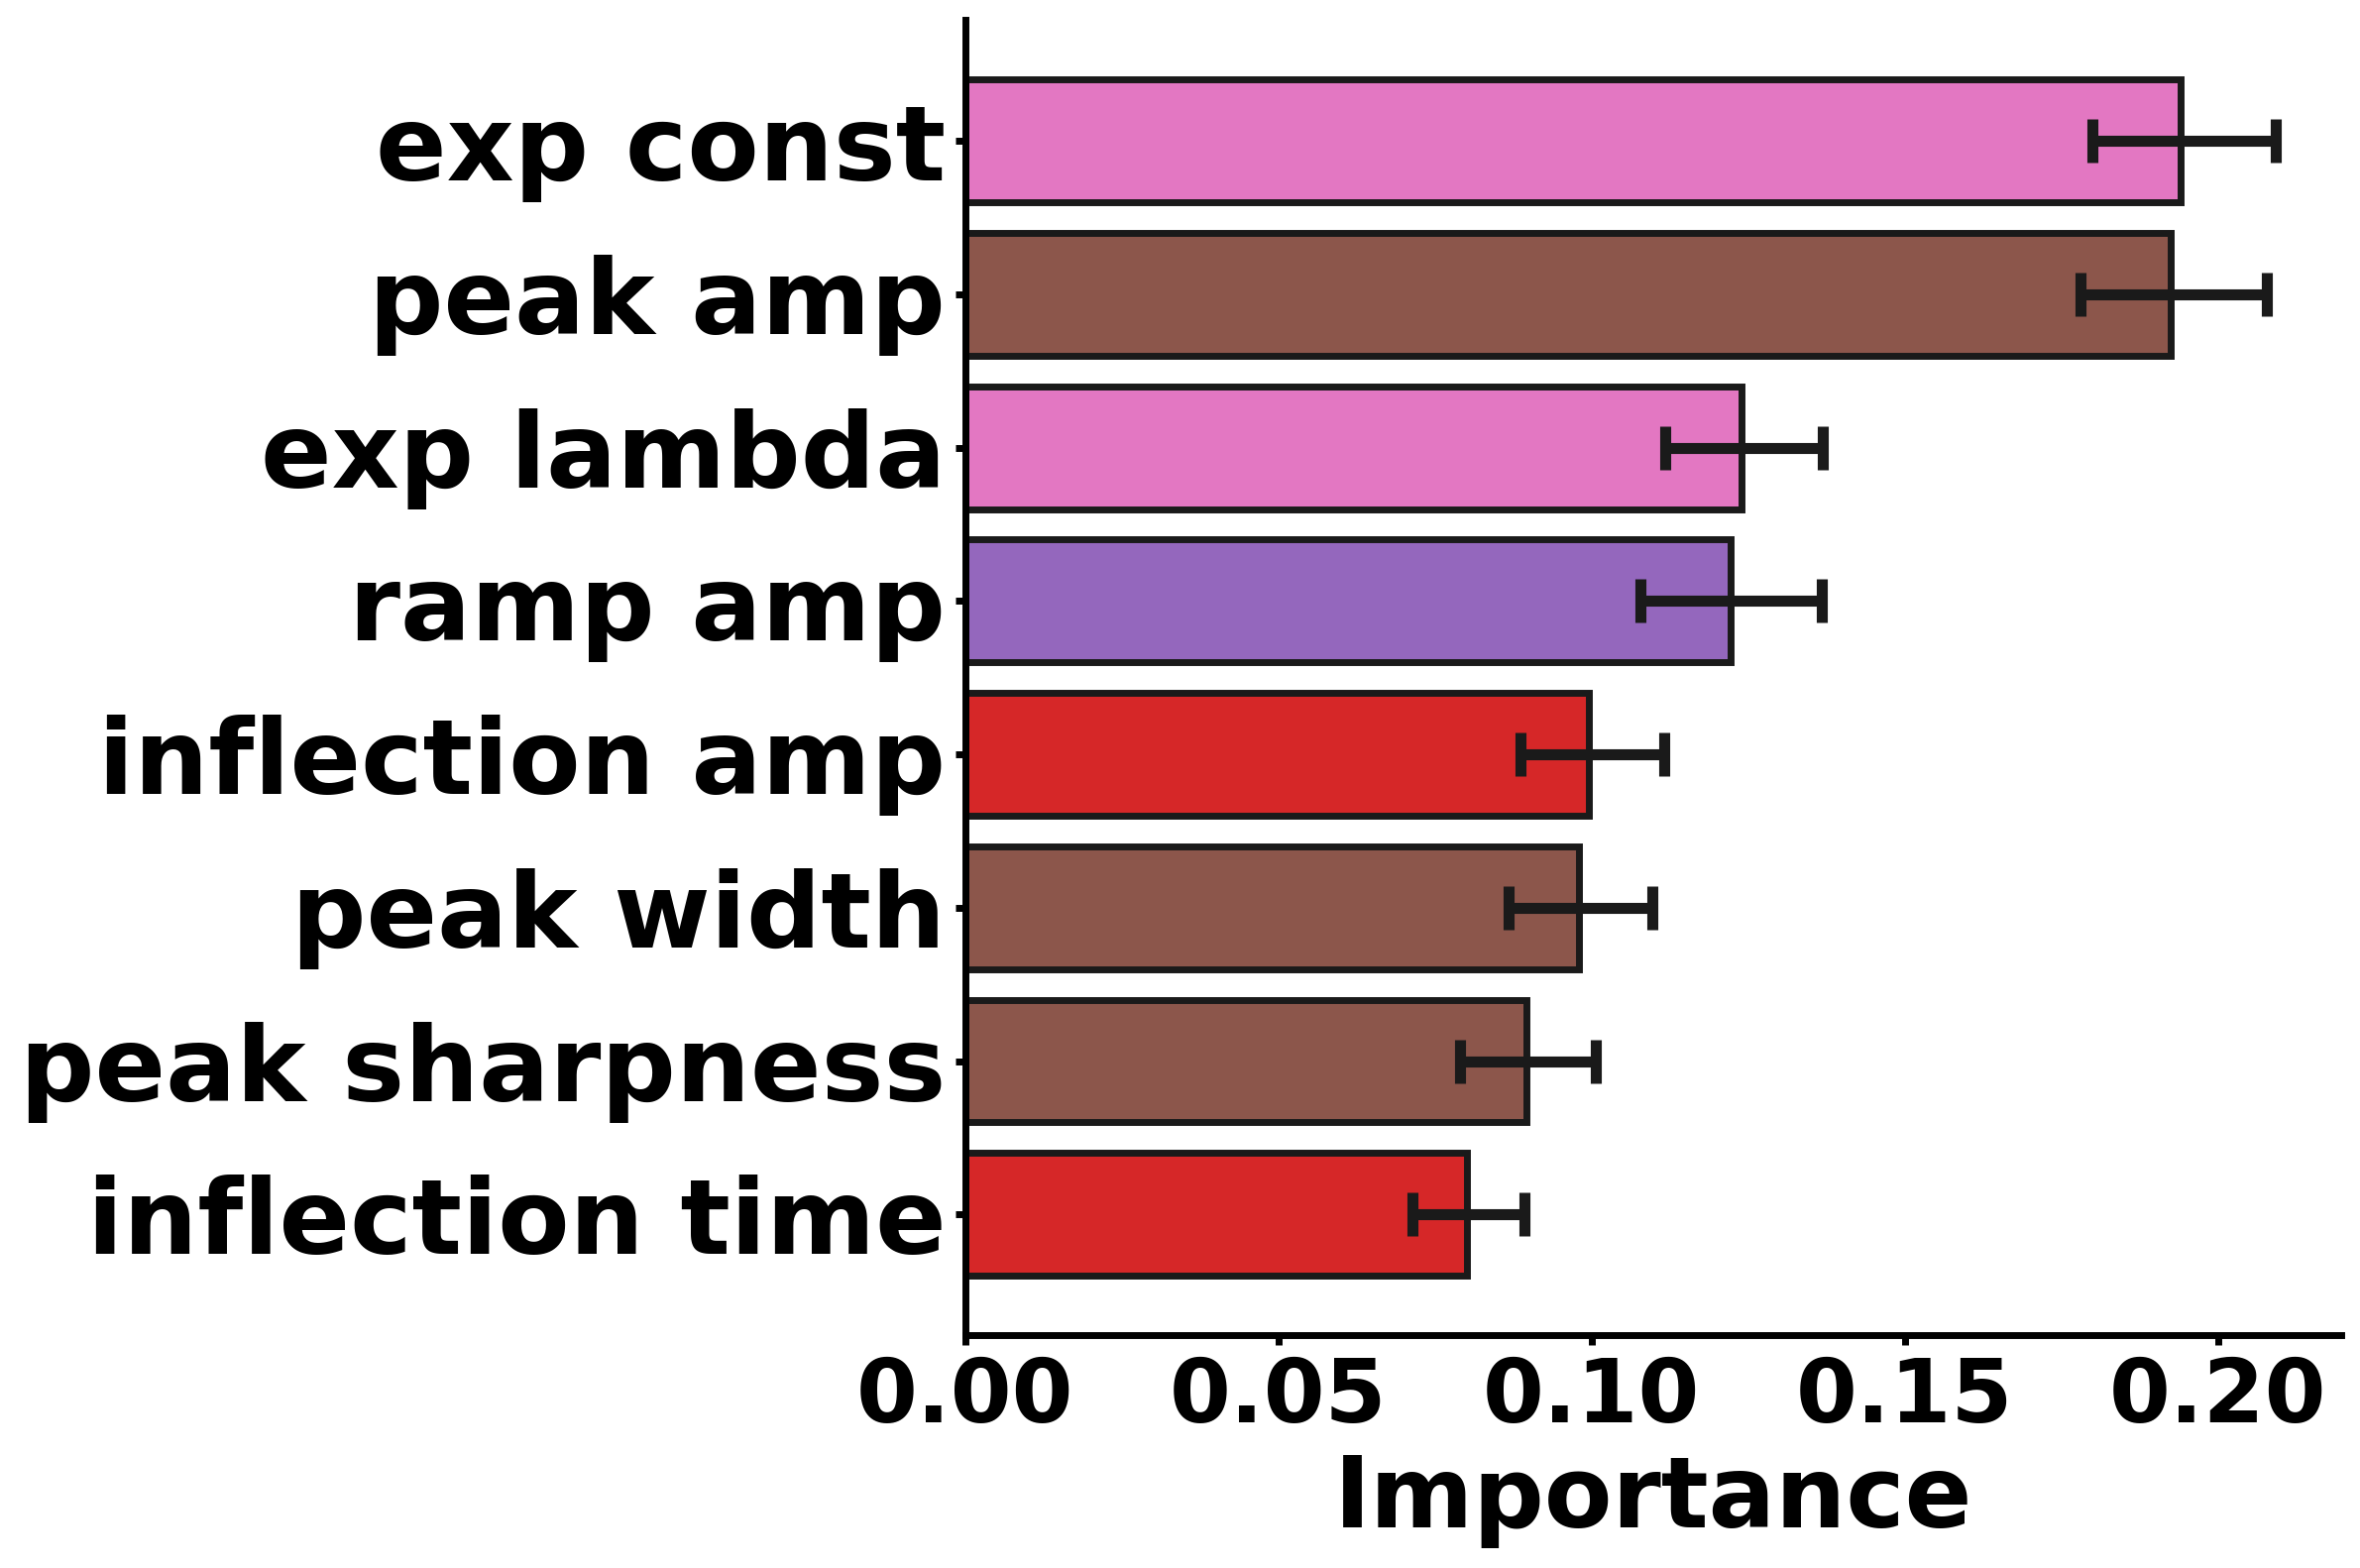

In [2]:
# Fig 3C -- same code as spk_waveform_stim_predictors_cell1_main.ipynb, cells 85-86.
# rf_model.pkl / rf_repeated_oof.pkl are the exact cached artifacts the paper figure uses:
# a GridSearchCV-tuned RandomForestClassifier decoding stim_type from waveform features only,
# evaluated via 1000 repeated out-of-fold 5-fold splits over all 820 spikes.
with open(PVC6_PICKLE_DIR + 'rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)
with open(PVC6_PICKLE_DIR + 'rf_repeated_oof.pkl', 'rb') as f:
    rep_accuracies, rep_cms, rep_importances = pickle.load(f)

print(f'Out-of-fold accuracy: {rep_accuracies.mean():.3f} +/- {rep_accuracies.std():.3f} '
      f'(1000 repeats, chance = 0.333)')

# X is only needed here for its column names (feature labels); rf_model already carries them.
X_dummy = pd.DataFrame(columns=rf_model.feature_names_in_)
mean_cm = rep_cms.mean(axis=0)
plot_confusion_matrix(rf_model, X_dummy, None, cm=np.round(mean_cm).astype(int))
plot_feature_importance_categorical(rf_model, X_dummy, rep_importances)

Beta weights (bootstrap t-test vs 0), BH-FDR across 24 tests:
      tgt            feat      coef          pval          qval  sig_fdr
 stim_exp        peak_amp -0.564623  0.000000e+00  0.000000e+00     True
 stim_exp  peak_sharpness  0.598909  0.000000e+00  0.000000e+00     True
 stim_exp      exp_lambda  0.552933  0.000000e+00  0.000000e+00     True
 stim_exp       exp_const -0.176288  0.000000e+00  0.000000e+00     True
 stim_exp        ramp_amp -0.049969 1.184573e-233 1.672338e-233     True
 stim_exp      peak_width  0.084487  3.823290e-56  4.829419e-56     True
 stim_exp  inflection_amp  0.040140  6.004228e-26  7.205074e-26     True
 stim_exp inflection_time  0.023461  8.023008e-17  9.169152e-17     True
stim_mean        peak_amp  0.776982  0.000000e+00  0.000000e+00     True
stim_mean  peak_sharpness -0.647036  0.000000e+00  0.000000e+00     True
stim_mean      exp_lambda -0.690527  0.000000e+00  0.000000e+00     True
stim_mean       exp_const  0.627804  0.000000e+00  0.000000e+0

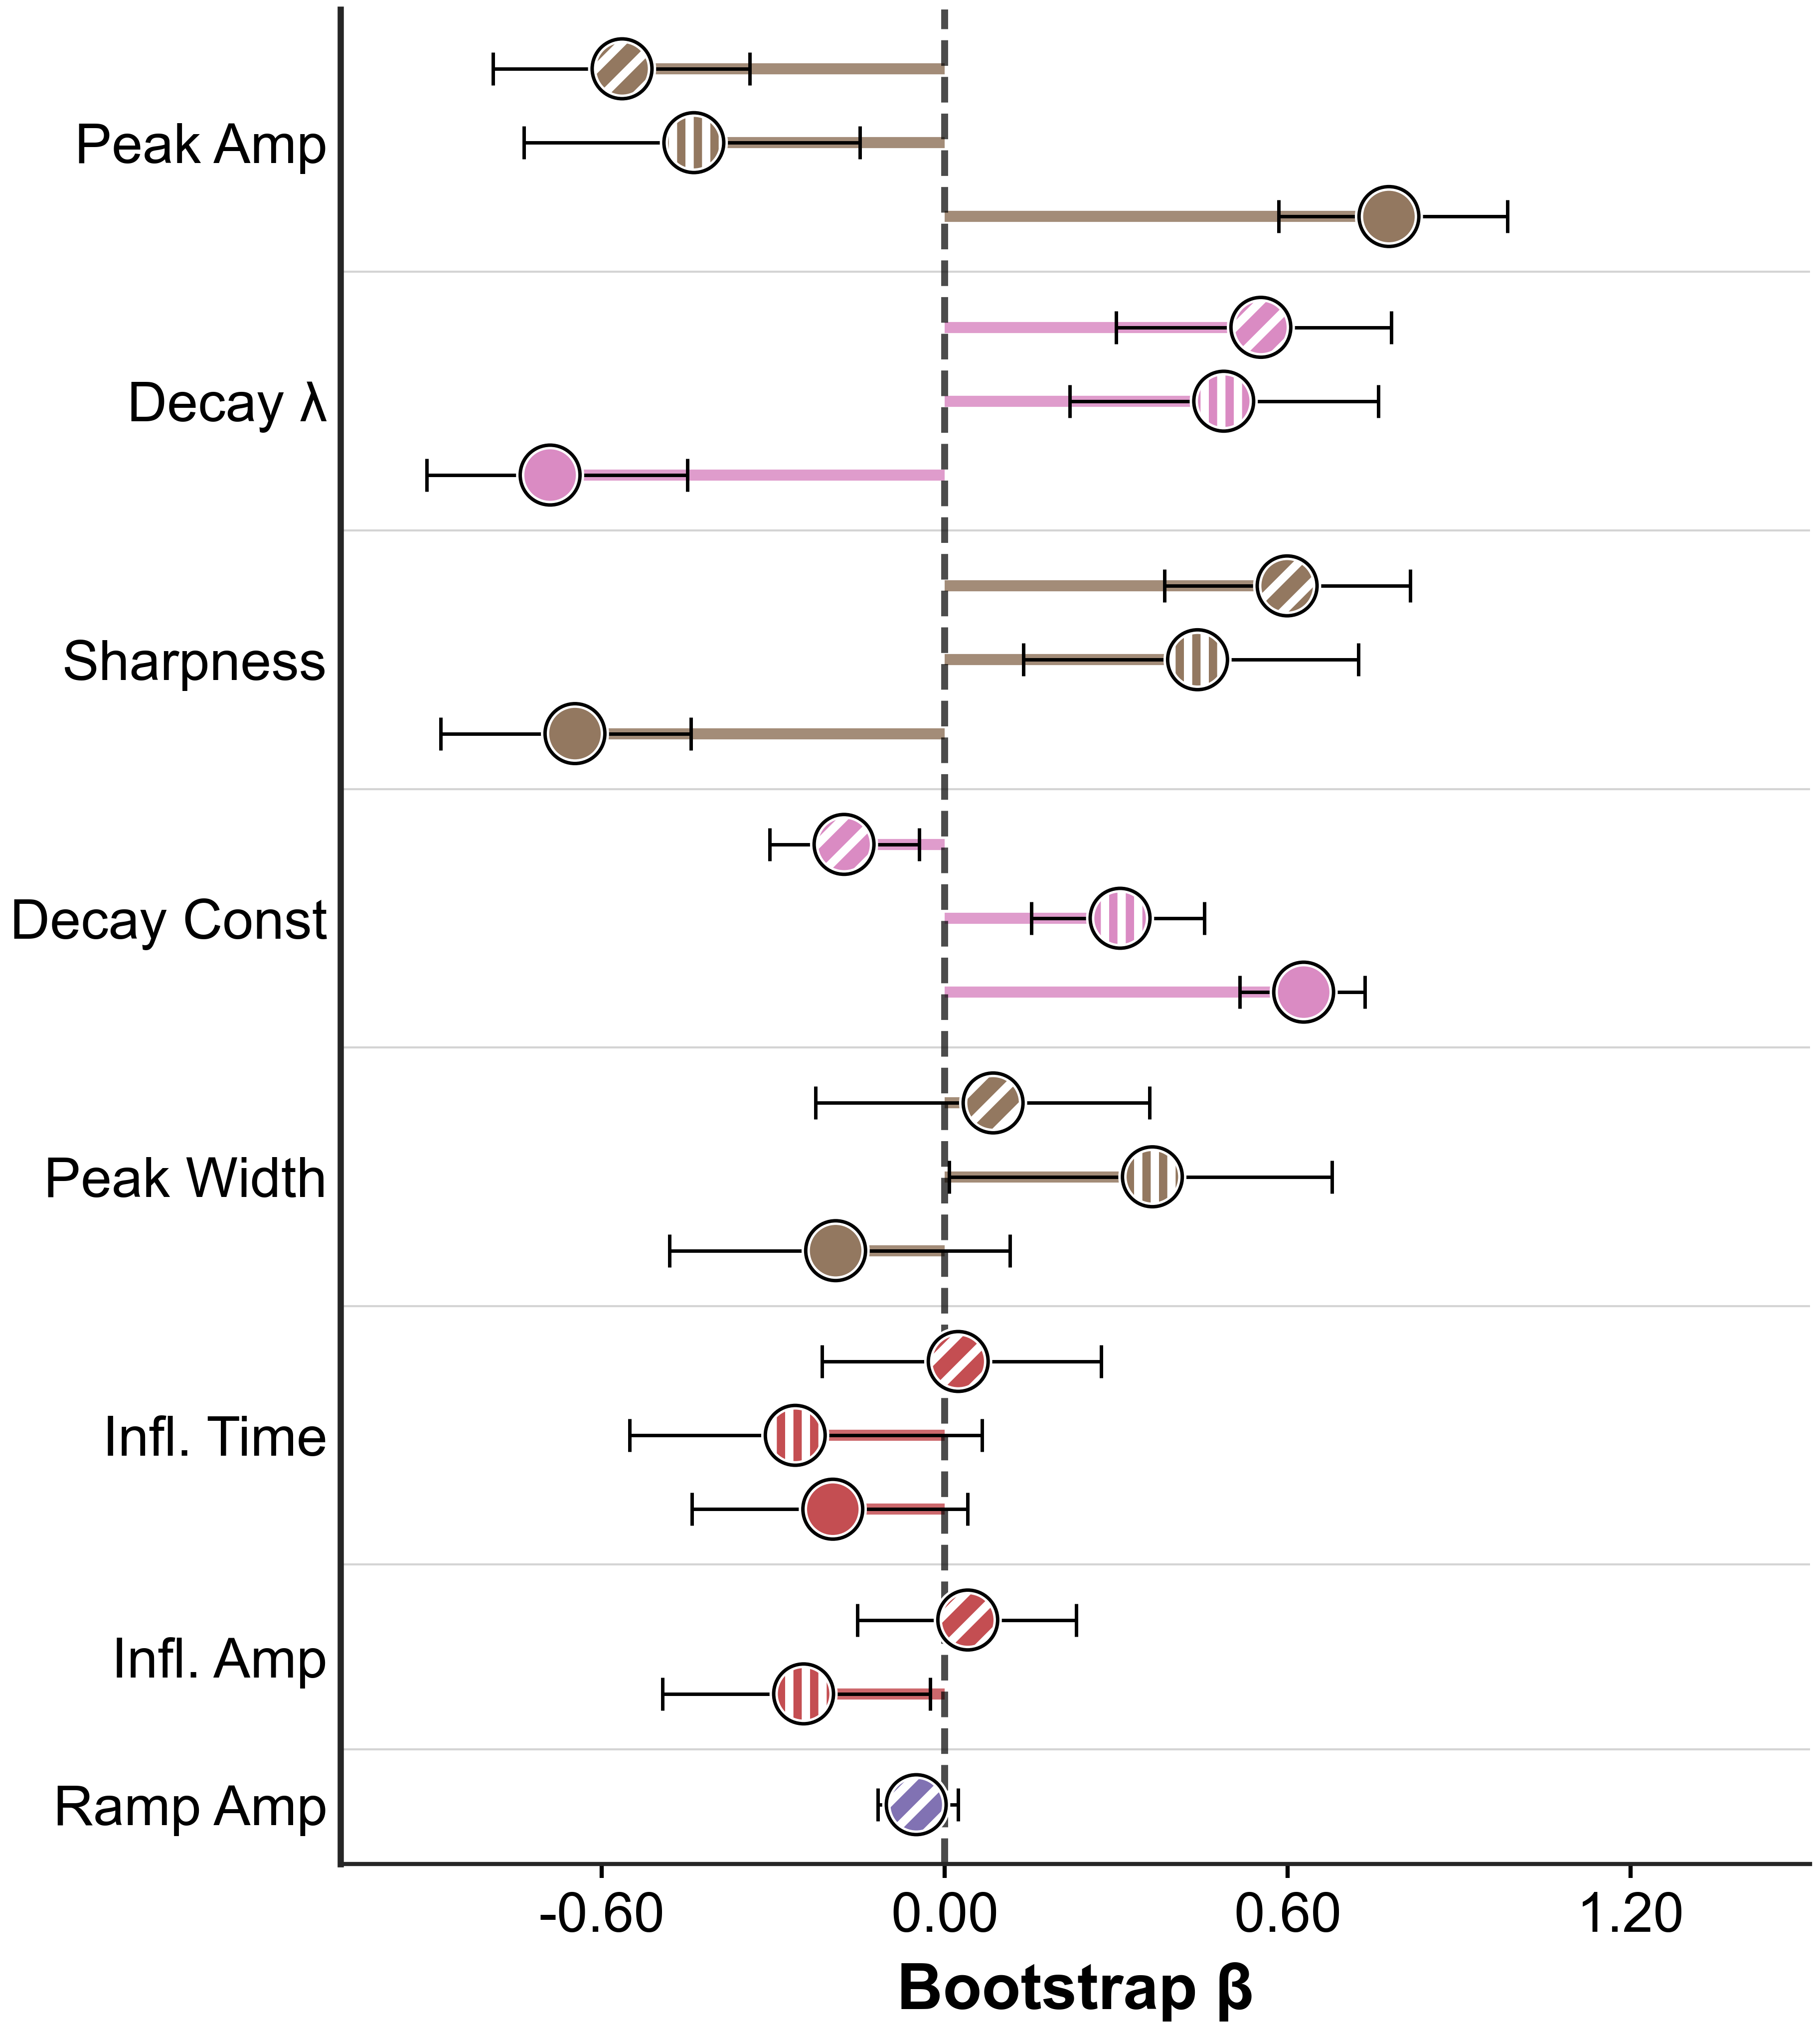

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/pvc-6/pvc6_helper_modules/pvc6_plotting.py:1371: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


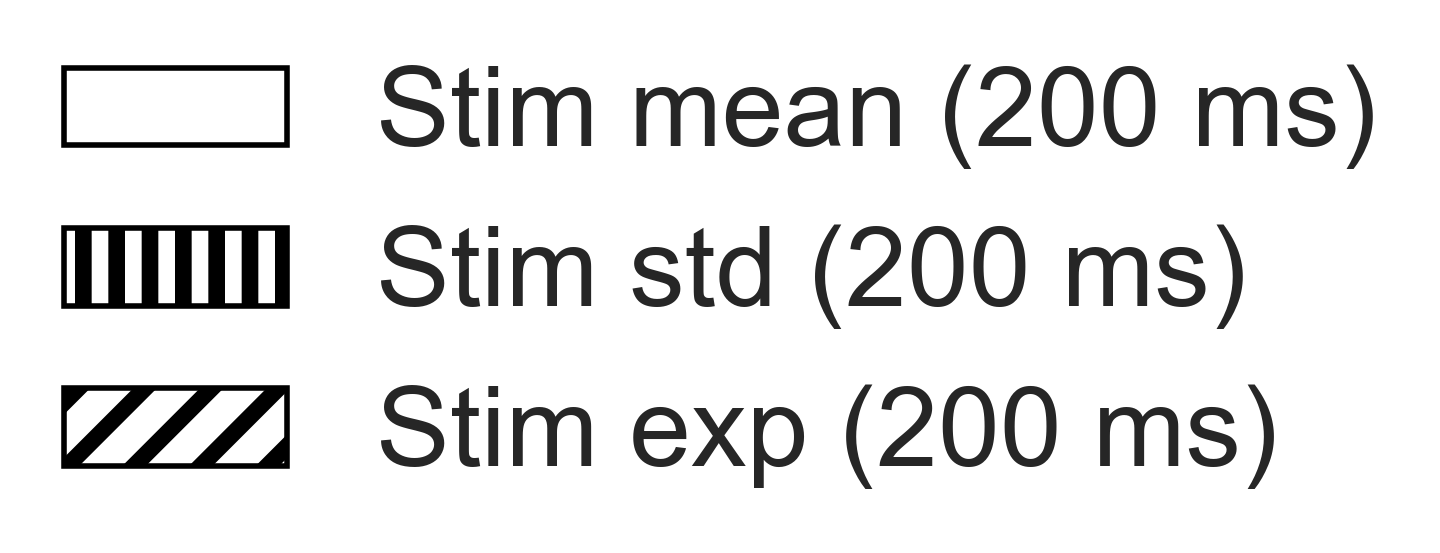

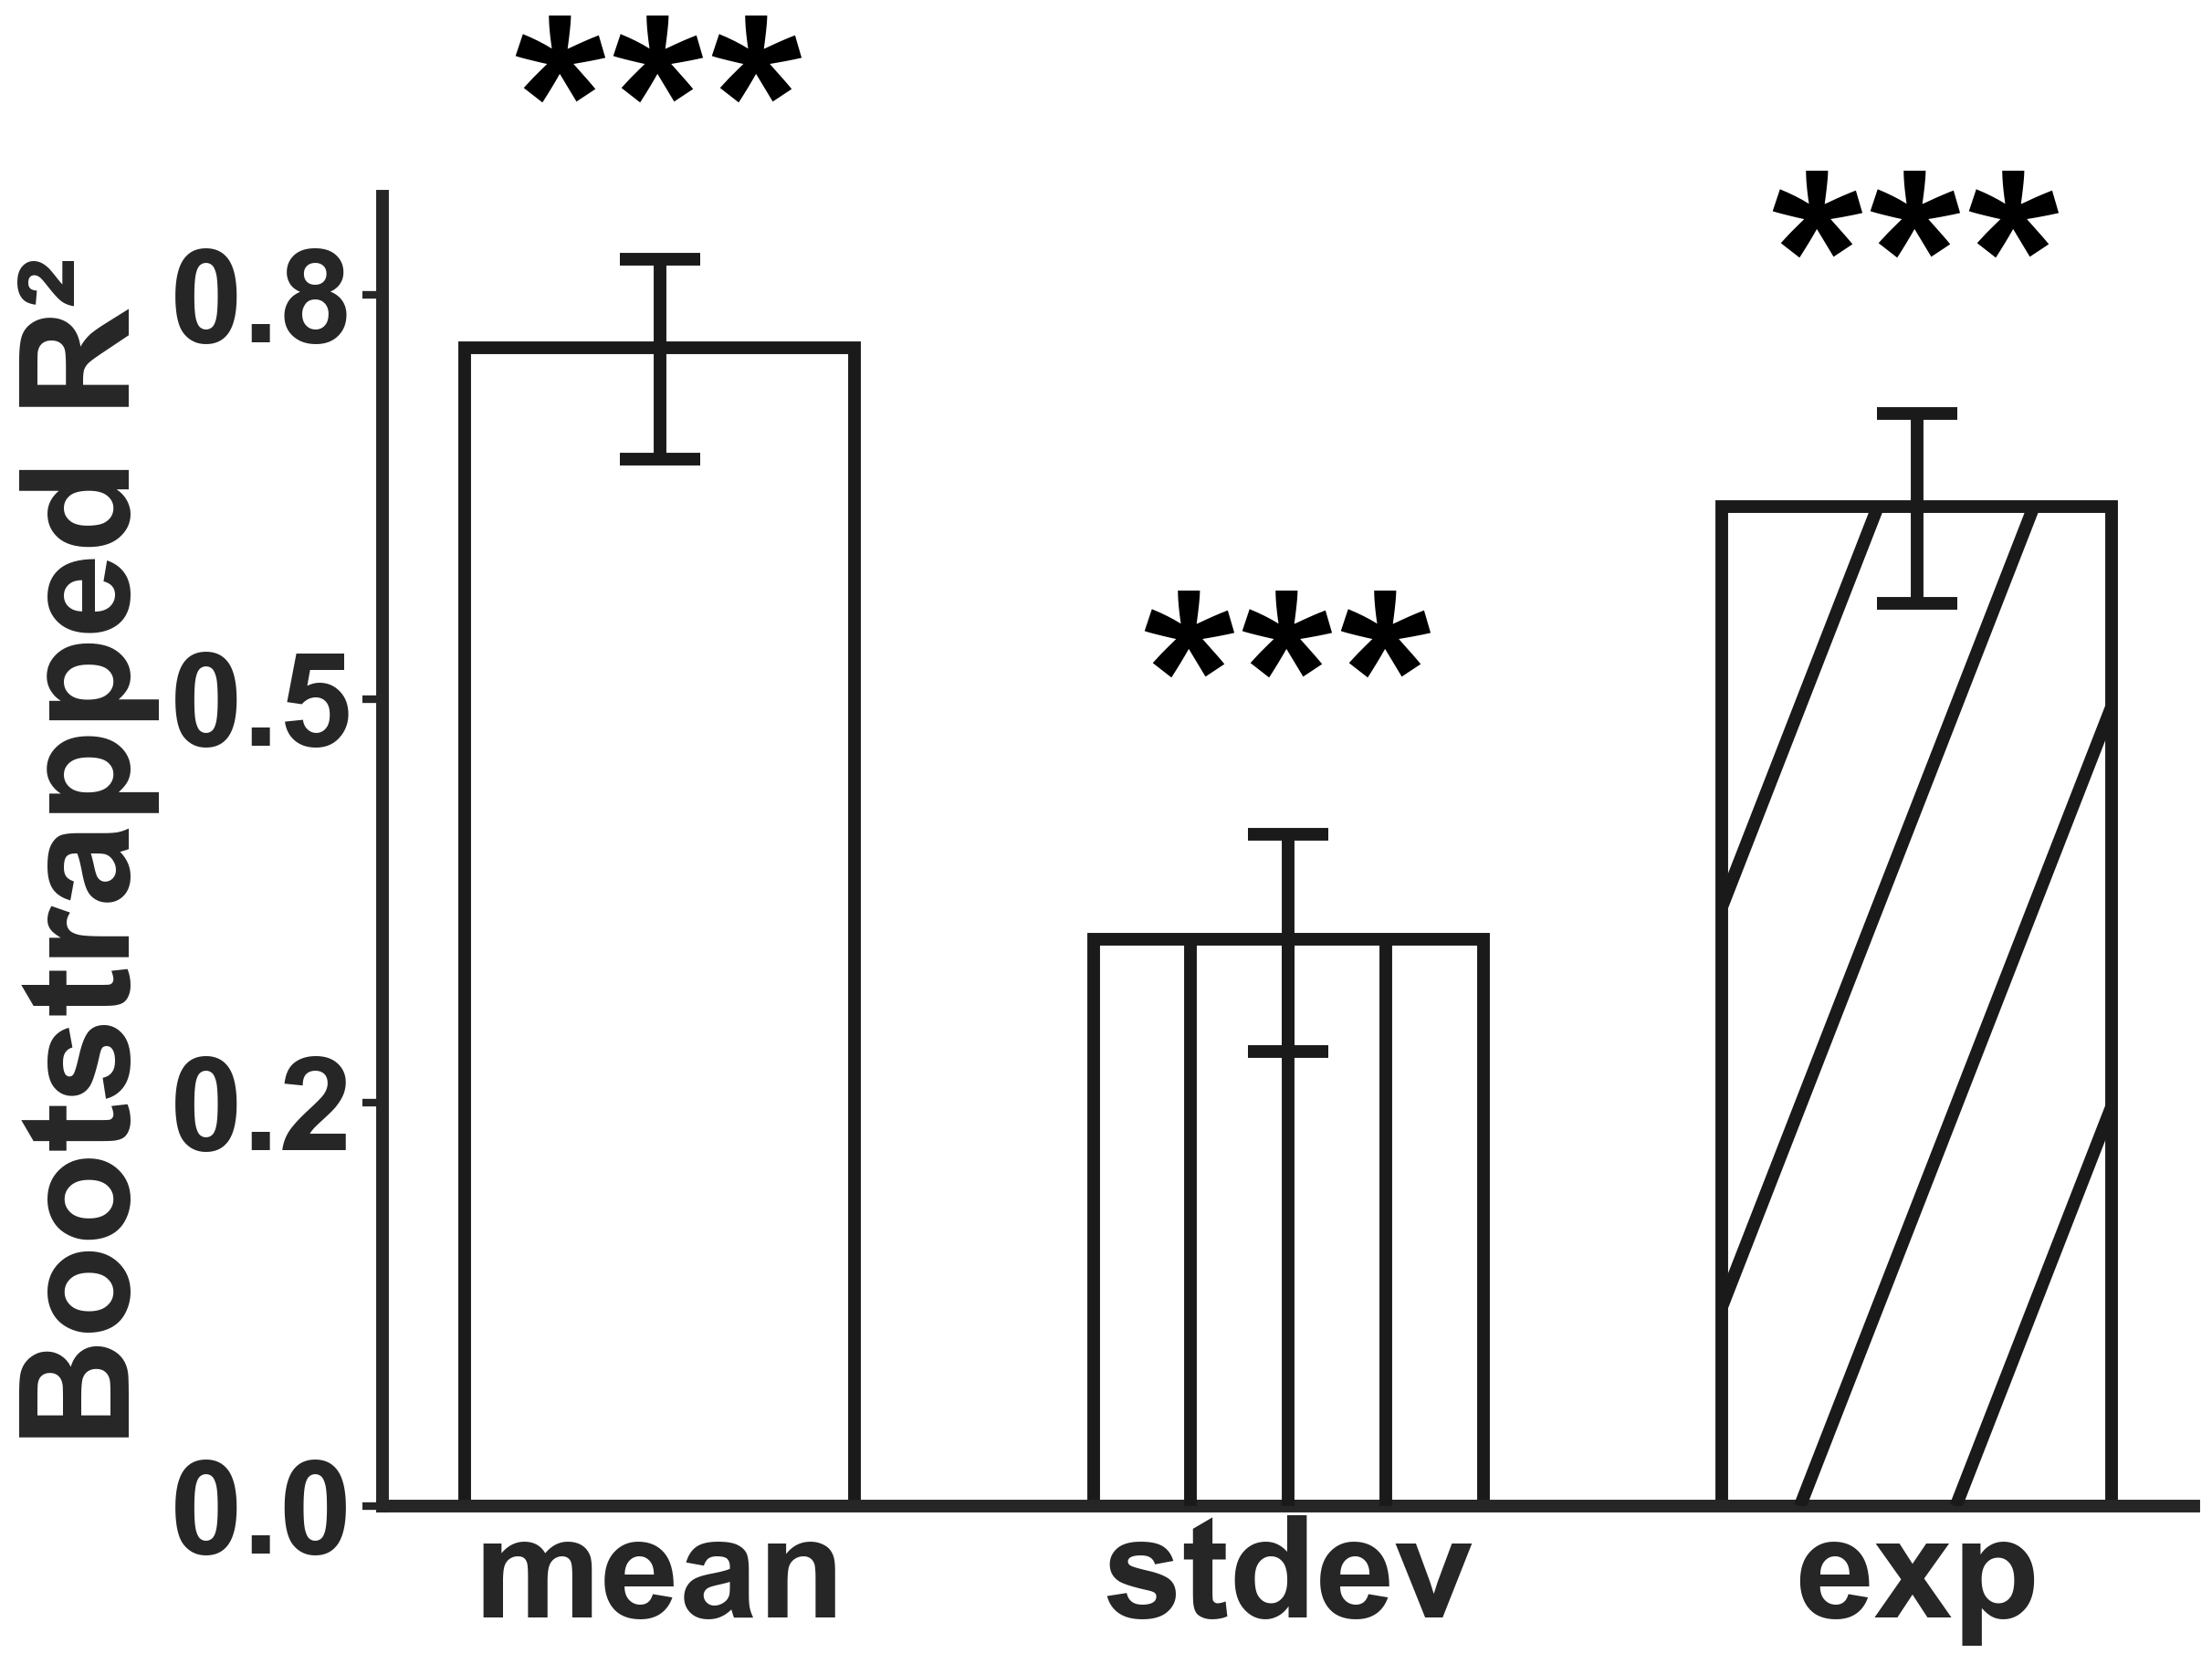

PAPER-REPORTED VALUES -- 200 ms pre-spike window
  Mean amplitude          R2 = 0.717  95% CI [0.648, 0.772]  p = 0.001
  Amplitude variance      R2 = 0.351  95% CI [0.282, 0.416]  p = 0.001
  Spectral exponent       R2 = 0.619  95% CI [0.559, 0.676]  p = 0.001


In [3]:
# Fig 3F -- same code as spk_waveform_stim_predictors_cell1_main.ipynb, cells 59-60
# ("Paper-reported values (200 ms window)" section).
with open(PVC6_PICKLE_DIR + 'results_window.pkl', 'rb') as f:
    results_window = pickle.load(f)

plot_beta_weights_combined(results_window, window_ms=200)

print('=' * 55)
print('PAPER-REPORTED VALUES -- 200 ms pre-spike window')
print('=' * 55)
for _t, _label in [('stim_mean', 'Mean amplitude'),
                   ('stim_std',  'Amplitude variance'),
                   ('stim_exp',  'Spectral exponent')]:
    _res = results_window[f'200ms_{_t}']
    _r2, _ci, _p = _res['r2_mean'], _res['r2_ci'], _res['p_val_perm']
    print(f'  {_label:<22}  R2 = {_r2:.3f}  95% CI [{_ci[0]:.3f}, {_ci[1]:.3f}]  p = {_p:.3f}')
print('=' * 55)